In [ ]:
# Check if GPU is available and set random seeds for reproducibility
import torch
import numpy as np
import random
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"

# Set seeds
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Check GPU
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    torch.cuda.empty_cache()



CUDA Available: True
GPU Name: Tesla T4
GPU Memory: 15.64 GB


In [ ]:
pip install --upgrade timm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls /content/drive/MyDrive/dataset-NCKH-SignDETR-VSL/

dataset_combined.zip  datasetfilnal_v3.zip  dataset.zip
datasetfilnal_v2.zip  datasetfilnal_v4.zip  final_dataset_vsl.zip


In [ ]:
# !rm -rf /content/SignDETR-VSL


In [ ]:
import os
import shutil
import zipfile

# Khai báo các đường dẫn
source_path = '/content/drive/MyDrive/dataset-NCKH-SignDETR-VSL/datasetfilnal_v4.zip'
dest_zip = '/content/datasetfilnal_v4.zip'
extract_dir = '/content/SignDETR-VSL'

# 1. Kiểm tra xem thư mục đích đã tồn tại và có dữ liệu bên trong chưa
if os.path.exists(extract_dir) and len(os.listdir(extract_dir)) > 0:
    print("✅ Dataset đã được giải nén sẵn trong máy. Bỏ qua bước copy và unzip!")
else:
    print("⚠️ Chưa có dataset sẵn sàng. Bắt đầu xử lý...")

    # 2. Kiểm tra xem file zip đã được copy xuống Colab chưa
    if not os.path.exists(dest_zip):
        print("⏳ Đang copy file zip từ Google Drive xuống...")
        if os.path.exists(source_path):
            shutil.copy(source_path, dest_zip)
            print("✅ Copy từ Drive hoàn tất!")
        else:
            print("❌ LỖI: Không tìm thấy file zip trên Drive. Bạn đã mount Drive chưa?")
            raise FileNotFoundError("Không tìm thấy file trên Google Drive.")
    else:
        print("✅ File zip đã có sẵn ở '/content/'. Bỏ qua bước copy từ Drive.")

    # 3. Tiến hành giải nén
    print("⏳ Đang tiến hành giải nén...")
    os.makedirs(extract_dir, exist_ok=True)
    with zipfile.ZipFile(dest_zip, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

    print("🎉 Hoàn tất chuẩn bị dữ liệu!")

✅ Dataset đã được giải nén sẵn trong máy. Bỏ qua bước copy và unzip!


In [ ]:
import os

ROOT = "/content/SignDETR-VSL"
splits = ["train", "valid", "test"]

def count_files(path, exts):
    return len([f for f in os.listdir(path) if f.lower().endswith(exts)])

for split in splits:
    img_dir = f"{ROOT}/{split}/images"
    lbl_dir = f"{ROOT}/{split}/labels"

    n_imgs = count_files(img_dir, (".jpg", ".png", ".jpeg"))
    n_lbls = count_files(lbl_dir, (".txt",))

    print(f"{split.upper():5} | images: {n_imgs:5} | labels: {n_lbls:5}")


TRAIN | images:  2134 | labels:  2134
VALID | images:   616 | labels:   616
TEST  | images:   329 | labels:   329


In [ ]:
def filename_set(path, ext):
    return set(os.path.splitext(f)[0] for f in os.listdir(path) if f.endswith(ext))

for split in splits:
    img_dir = f"{ROOT}/{split}/images"
    lbl_dir = f"{ROOT}/{split}/labels"

    imgs = filename_set(img_dir, ".jpg") | filename_set(img_dir, ".png")
    lbls = filename_set(lbl_dir, ".txt")

    missing_lbl = imgs - lbls
    missing_img = lbls - imgs

    print(f"\n[{split.upper()}]")
    print("Missing labels:", len(missing_lbl))
    print("Missing images:", len(missing_img))



[TRAIN]
Missing labels: 0
Missing images: 0

[VALID]
Missing labels: 0
Missing images: 0

[TEST]
Missing labels: 0
Missing images: 0


In [ ]:
!find /content/SignDETR-VSL -maxdepth 2 -type d


/content/SignDETR-VSL
/content/SignDETR-VSL/train
/content/SignDETR-VSL/train/labels
/content/SignDETR-VSL/train/images
/content/SignDETR-VSL/test
/content/SignDETR-VSL/test/labels
/content/SignDETR-VSL/test/images
/content/SignDETR-VSL/valid
/content/SignDETR-VSL/valid/labels
/content/SignDETR-VSL/valid/images


In [ ]:
def filename_set(path, ext):
    return set(os.path.splitext(f)[0] for f in os.listdir(path) if f.endswith(ext))

for split in splits:
    img_dir = f"{ROOT}/{split}/images"
    lbl_dir = f"{ROOT}/{split}/labels"

    imgs = filename_set(img_dir, ".jpg") | filename_set(img_dir, ".png")
    lbls = filename_set(lbl_dir, ".txt")

    missing_lbl = imgs - lbls
    missing_img = lbls - imgs

    print(f"\n[{split.upper()}]")
    print("Missing labels:", len(missing_lbl))
    print("Missing images:", len(missing_img))



[TRAIN]
Missing labels: 0
Missing images: 0

[VALID]
Missing labels: 0
Missing images: 0

[TEST]
Missing labels: 0
Missing images: 0


In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

LABEL_ID = 5  # đổi nhãn bạn muốn xem

IMG_DIR = "/content/SignDETR-VSL/train/images"
LBL_DIR = "/content/SignDETR-VSL/train/labels"

images_with_label = []

for lbl_file in os.listdir(LBL_DIR):
    lbl_path = os.path.join(LBL_DIR, lbl_file)
    with open(lbl_path, "r") as f:
        for line in f:
            if int(line.split()[0]) == LABEL_ID:
                img_name = lbl_file.replace(".txt", ".jpg")  # hoặc .png
                images_with_label.append(img_name)
                break

print(f"Tìm thấy {len(images_with_label)} ảnh có nhãn {LABEL_ID}")

Tìm thấy 97 ảnh có nhãn 5


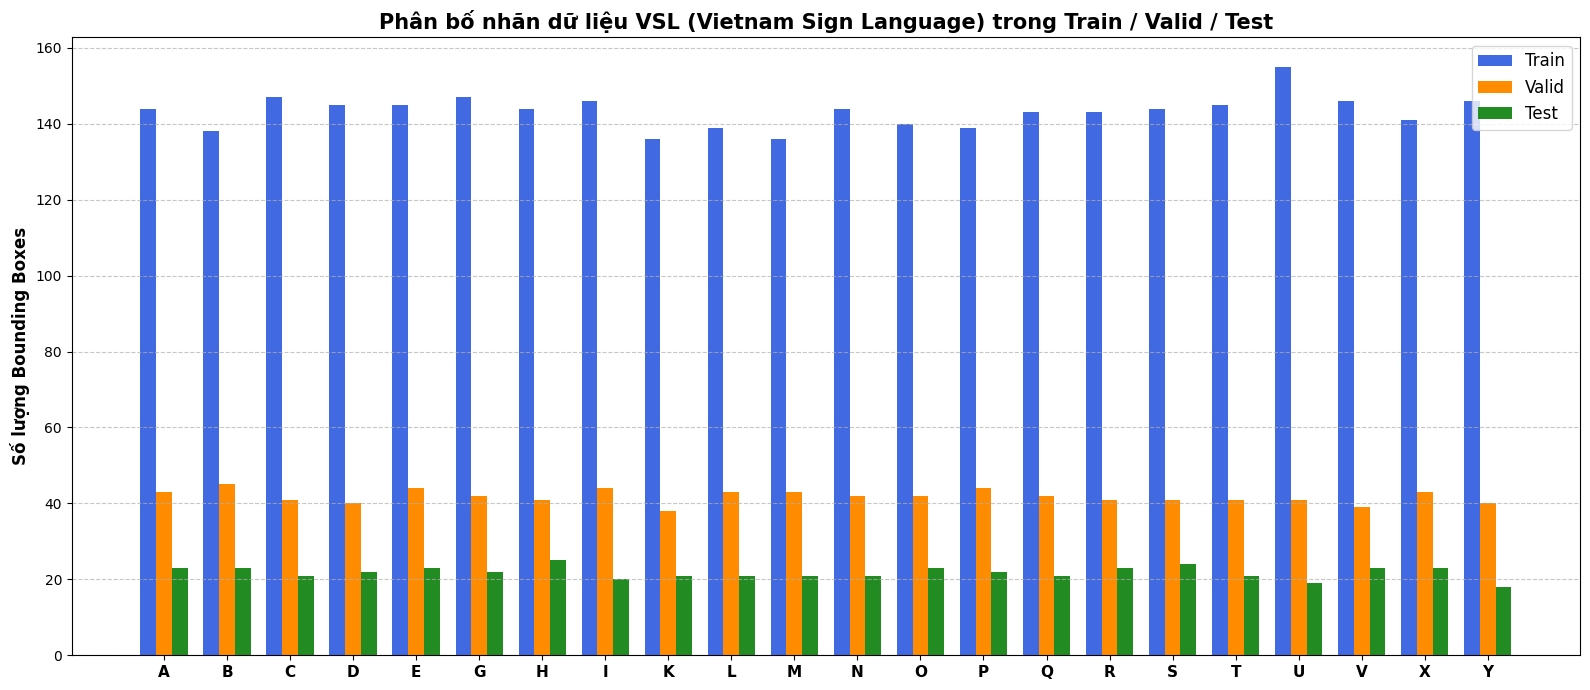


✅ Dataset sạch sẽ, không có ID nhãn nào vượt quá giới hạn 0-22.


In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np

DATA_DIR = "/content/SignDETR-VSL/"
splits = ['train', 'valid', 'test']
CLASSES = ['A', 'B', 'C', 'D', 'E', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'X', 'Y']
# Khởi tạo dictionary để đếm số lượng bbox
counts = {split: {i: 0 for i in range(len(CLASSES))} for split in splits}
invalid_labels = []

# Quét file labels
for split in splits:
    lbl_dir = os.path.join(DATA_DIR, split, 'labels')
    if not os.path.exists(lbl_dir):
        continue

    for file in os.listdir(lbl_dir):
        if file.endswith('.txt'):
            with open(os.path.join(lbl_dir, file), 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) > 0:
                        cls_id = int(parts[0])
                        # Nếu ID nằm trong danh sách chuẩn
                        if 0 <= cls_id < len(CLASSES):
                            counts[split][cls_id] += 1
                        else:
                            invalid_labels.append((split, file, cls_id))

# Vẽ biểu đồ
x = np.arange(len(CLASSES))
width = 0.25  # Độ rộng của mỗi cột

fig, ax = plt.subplots(figsize=(16, 7))

train_counts = [counts['train'][i] for i in range(len(CLASSES))]
valid_counts = [counts['valid'][i] for i in range(len(CLASSES))]
test_counts = [counts['test'][i] for i in range(len(CLASSES))]

# Tạo các cột
rects1 = ax.bar(x - width, train_counts, width, label='Train', color='royalblue')
rects2 = ax.bar(x, valid_counts, width, label='Valid', color='darkorange')
rects3 = ax.bar(x + width, test_counts, width, label='Test', color='forestgreen')

# Trang trí biểu đồ
ax.set_ylabel('Số lượng Bounding Boxes', fontsize=12, fontweight='bold')
ax.set_title('Phân bố nhãn dữ liệu VSL (Vietnam Sign Language) trong Train / Valid / Test', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(CLASSES, fontsize=11, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# In cảnh báo nếu có nhãn rác
if invalid_labels:
    print("\n⚠️ CẢNH BÁO: Phát hiện các nhãn rác (ID >= 23 hoặc < 0) trong Dataset!")
    print(f"Tổng số nhãn rác: {len(invalid_labels)}")
    print("5 ví dụ đầu tiên:", invalid_labels[:5])
else:
    print("\n✅ Dataset sạch sẽ, không có ID nhãn nào vượt quá giới hạn 0-22.")

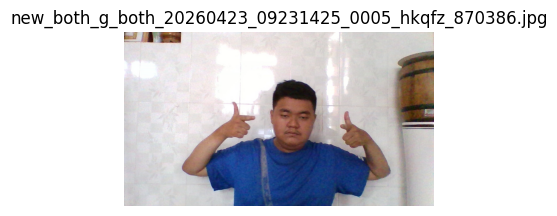

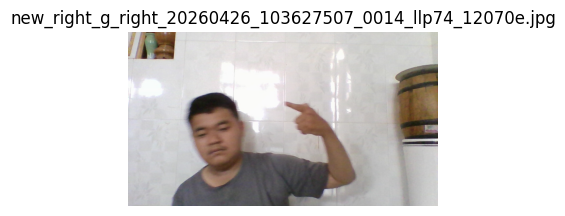

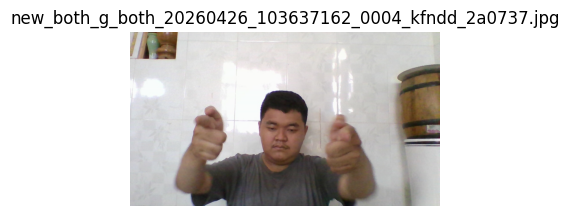

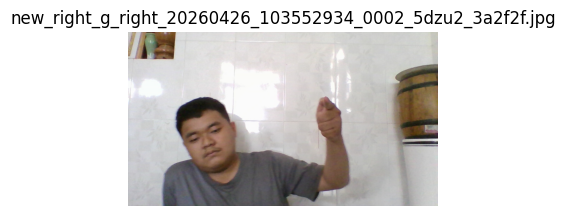

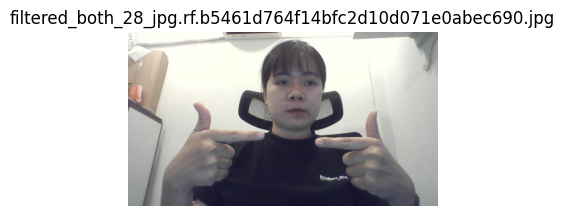

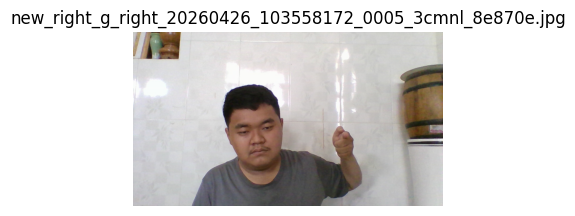

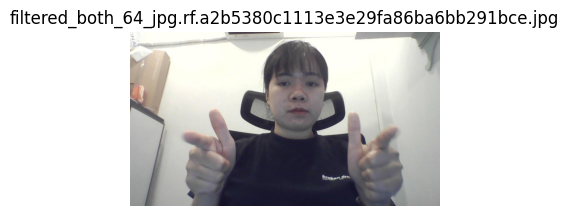

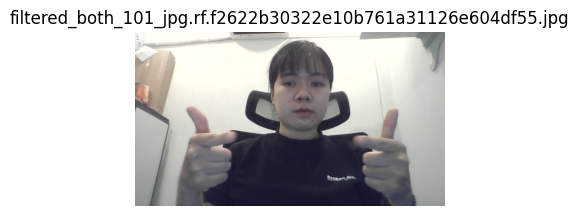

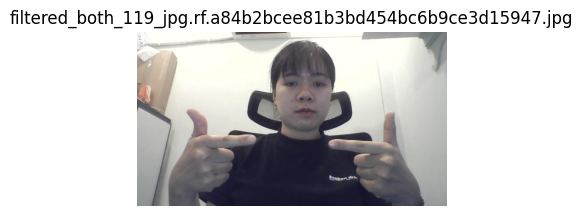

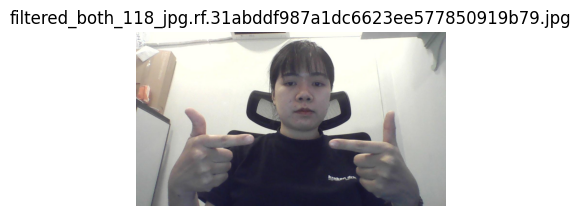

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

for img_name in images_with_label[:10]:
    img_path = os.path.join(IMG_DIR, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_name)
    plt.show()

In [ ]:
def draw_yolo_bbox(img, label_path):
    h, w, _ = img.shape
    with open(label_path, "r") as f:
        for line in f:
            cls, xc, yc, bw, bh = map(float, line.split())
            x1 = int((xc - bw/2) * w)
            y1 = int((yc - bh/2) * h)
            x2 = int((xc + bw/2) * w)
            y2 = int((yc + bh/2) * h)
            cv2.rectangle(img, (x1,y1), (x2,y2), (255,0,0), 2)
    return img

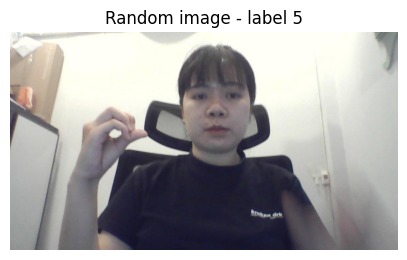

In [ ]:
import random

random_img = random.choice(images_with_label)

img_path = os.path.join(IMG_DIR, random_img)
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.title(f"Random image - label {LABEL_ID}")
plt.show()

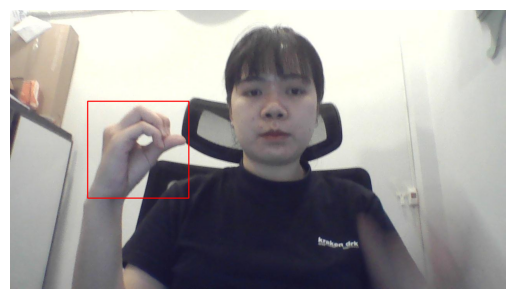

In [ ]:
lbl_path = os.path.join(LBL_DIR, random_img.replace(".jpg", ".txt"))
img_box = draw_yolo_bbox(img.copy(), lbl_path)

plt.imshow(img_box)
plt.axis("off")
plt.show()

In [ ]:
names = ['A', 'B', 'C', 'D', 'E', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'X', 'Y']

id2name = {i: name for i, name in enumerate(names)}
name2id = {name: i for i, name in enumerate(names)}

print(id2name)

{0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'G', 6: 'H', 7: 'I', 8: 'K', 9: 'L', 10: 'M', 11: 'N', 12: 'O', 13: 'P', 14: 'Q', 15: 'R', 16: 'S', 17: 'T', 18: 'U', 19: 'V', 20: 'X', 21: 'Y'}


In [ ]:
import subprocess
import sys

packages = [
    'albumentations',
    'colorama',
    'rich',
    'torchinfo',
    'scipy'
]

print("Installing required packages...")
for package in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

print("All packages installed successfully!")

# Verify PyTorch installation
print(f"\nPyTorch version: {torch.__version__}")
print(f"TorchVision version: {__import__('torchvision').__version__}")

Installing required packages...
All packages installed successfully!

PyTorch version: 2.10.0+cu128
TorchVision version: 0.25.0+cu128


## mô hình DETR

In [ ]:
# Define DETR Model
import torch
from torch import nn
import timm#
import math

def _get_1d_sincos_pos_embed(length: int, dim: int, temperature: float = 10000.0, device=None):
    assert dim % 2 == 0
    position = torch.arange(length, device=device, dtype=torch.float32).unsqueeze(1)
    div_term = torch.exp(
        torch.arange(0, dim, 2, device=device, dtype=torch.float32) * (-math.log(temperature) / dim)
    )
    pe = torch.zeros(length, dim, device=device, dtype=torch.float32)
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe

def build_2d_sincos_position_embedding(height: int, width: int, dim: int, device=None):
    assert dim % 2 == 0, "positional dim must be even"
    dim_half = dim // 2
    pe_y = _get_1d_sincos_pos_embed(height, dim_half, device=device)
    pe_x = _get_1d_sincos_pos_embed(width, dim_half, device=device)
    pos = torch.zeros(height, width, dim, device=device, dtype=torch.float32)
    pos[:, :, :dim_half] = pe_y[:, None, :].expand(-1, width, -1)
    pos[:, :, dim_half:] = pe_x[None, :, :].expand(height, -1, -1)
    pos = pos.view(1, height * width, dim)
    return pos

class DETR(nn.Module):
    def __init__(self, num_classes, hidden_dim=256, nheads=8,
                 num_encoder_layers=1, num_decoder_layers=1, num_queries=25):
        super().__init__()


                # 'tiny_vit_5m_224'  -> Siêu nhẹ
                 # 'tiny_vit_11m_224' -> Cân bằng (Khuyên dùng cho đồ án)
                 # 'tiny_vit_21m_224' -> Mạnh nhất dòng Tiny
        # ResNet-50 backbone
        self.backbone = timm.create_model(
            'tiny_vit_11m_224',
            pretrained=True,
            features_only=True,
            out_indices=(3,)       # Lấy stage cuối cùng
        )

        backbone_out_channels = self.backbone.feature_info[-1]['num_chs']
        # Conversion layer
        self.conv = nn.Conv2d(backbone_out_channels, hidden_dim, 1)



      # 3. Standard Transformer của PyTorch
        self.transformer = nn.Transformer(
            hidden_dim, nheads,
            num_encoder_layers,
            num_decoder_layers,
            batch_first=True,
            dropout=0.1
        )

        # 4. Heads dự đoán
        self.linear_class = nn.Linear(hidden_dim, num_classes + 1)
        self.linear_bbox = nn.Linear(hidden_dim, 4)

        # 5. Object Queries
        self.num_queries = num_queries
        self.query_pos = nn.Parameter(torch.randn(self.num_queries, hidden_dim))

        self.norm_src = nn.LayerNorm(hidden_dim)
        self.norm_tgt = nn.LayerNorm(hidden_dim)

    def forward(self, inputs):
        # Trích xuất đặc trưng không gian (Feature Extraction)
        # Output từ backbone là (Batch, Channels, H/32, W/32)
        features = self.backbone(inputs)[-1]

        # Projection (Batch, 256, H/32, W/32)
        feat = self.conv(features)
        bsz, d_model, Hf, Wf = feat.shape

        # Flatten thành chuỗi (Sequence) cho Transformer
        src = feat.flatten(2).permute(0, 2, 1)

        # Positional encoding dựa trên tọa độ thực tế của feature map
        pos = build_2d_sincos_position_embedding(Hf, Wf, d_model, device=feat.device)
        src = self.norm_src(src + pos)

        # Chuẩn bị Query cho Decoder
        tgt = torch.zeros(bsz, self.num_queries, d_model, device=feat.device)
        query_pos = self.query_pos.unsqueeze(0).expand(bsz, -1, -1)
        tgt = self.norm_tgt(tgt + query_pos)

        # Qua Transformer
        hs = self.transformer(src=src, tgt=tgt)

        return {
            'pred_logits': self.linear_class(hs),
            'pred_boxes': self.linear_bbox(hs).sigmoid()
        }

print("DETR model defined")

DETR model defined


In [ ]:
CLASSES = ['A', 'B', 'C', 'D', 'E', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'X', 'Y']

In [ ]:
# Define utility functions for boxes and data
from scipy.optimize import linear_sum_assignment
import torch.nn.functional as F

def box_cxcywh_to_xyxy(x):
    """Convert boxes from (cx, cy, w, h) to (x1, y1, x2, y2)"""
    x0, y0, w, h = x.unbind(-1)
    b = [(x0 - 0.5 * w), (y0 - 0.5 * h), (x0 + 0.5 * w), (y0 + 0.5 * h)]
    return torch.stack(b, dim=-1)

def generalized_box_iou(boxes1, boxes2):
    """Compute the IoU between boxes"""
    assert (boxes1[:, 2:] >= boxes1[:, :2]).all()
    assert (boxes2[:, 2:] >= boxes2[:, :2]).all()

    iou, union = box_iou(boxes1, boxes2)

    lt = torch.min(boxes1[:, None, :2], boxes2[:, :2])
    rb = torch.max(boxes1[:, None, 2:], boxes2[:, 2:])
    wh = (rb - lt).clamp(min=0)
    enc_area = wh[:, :, 0] * wh[:, :, 1]

    return iou - (enc_area - union) / enc_area

def box_iou(boxes1, boxes2):
    area1 = (boxes1[:, 2] - boxes1[:, 0]) * (boxes1[:, 3] - boxes1[:, 1])
    area2 = (boxes2[:, 2] - boxes2[:, 0]) * (boxes2[:, 3] - boxes2[:, 1])

    lt = torch.max(boxes1[:, None, :2], boxes2[:, :2])
    rb = torch.min(boxes1[:, None, 2:], boxes2[:, 2:])
    wh = (rb - lt).clamp(min=0)
    inter = wh[:, :, 0] * wh[:, :, 1]

    union = area1[:, None] + area2 - inter
    iou = inter / union
    return iou, union

def rescale_bboxes(out_bbox, size):
    """Rescale bounding boxes from normalized coordinates"""
    img_w, img_h = size
    b = box_cxcywh_to_xyxy(out_bbox)
    b = b * torch.tensor([img_w, img_h, img_w, img_h], dtype=b.dtype, device=b.device)
    return b

def stacker(batch):
    """Stack batch items"""
    images, targets = [], []
    for img, tgt in batch:
        images.append(img)
        targets.append(tgt)
    return torch.stack(images), targets

def get_classes():
    return CLASSES

def get_colors():
    return [(0, 255, 0), (255, 0, 0), (0, 0, 255)]

print("Utility functions defined")

Utility functions defined


In [ ]:
# Define Loss Functions
class HungarianMatcher(nn.Module):
    """Hungarian matching for DETR"""
    def __init__(self, weight_dict: dict):
        super().__init__()
        self.class_weighting = weight_dict.get('class_weighting')
        self.bbox_weighting = weight_dict.get('bbox_weighting')
        self.giou_weighting = weight_dict.get('giou_weighting')

    @torch.no_grad()
    def forward(self, yhat, y):
        indices = []
        for batch_idx, target in enumerate(y):
            batch_logits = yhat["pred_logits"][batch_idx]
            batch_boxes = yhat["pred_boxes"][batch_idx]
            batch_prob = batch_logits.softmax(-1)

            tgt_labels = target["labels"].to(torch.long)
            tgt_boxes = target["boxes"].to(batch_boxes.dtype)

            cost_class = -batch_prob[:, tgt_labels]
            cost_bbox = torch.cdist(batch_boxes, tgt_boxes, p=1)
            cost_giou = -generalized_box_iou(
                box_cxcywh_to_xyxy(batch_boxes),
                box_cxcywh_to_xyxy(tgt_boxes)
            )

            C_batch = (self.bbox_weighting * cost_bbox +
                      self.class_weighting * cost_class +
                      self.giou_weighting * cost_giou).cpu()

            ii, jj = linear_sum_assignment(C_batch)
            indices.append(
                (torch.as_tensor(ii, dtype=torch.int64), torch.as_tensor(jj, dtype=torch.int64))
            )
        return indices

class DETRLoss(nn.Module):
    """DETR Loss computation"""
    def __init__(self, num_classes, matcher, weight_dict, eos_coef):
        super().__init__()
        self.num_classes = num_classes
        self.matcher = matcher
        self.weight_dict = weight_dict
        self.eos_coef = eos_coef
        empty_weight = torch.ones(self.num_classes + 1)
        empty_weight[-1] = self.eos_coef
        self.register_buffer('empty_weight', empty_weight)

    def classification_loss(self, yhat, y, indices):
        src_logits = yhat['pred_logits']
        idx = self.get_matched_query_indices(indices)
        target_classes_o = torch.cat([t["labels"][J] for t, (_, J) in zip(y, indices)])
        target_classes = torch.full(src_logits.shape[:2], self.num_classes,
                                  dtype=torch.int64, device=src_logits.device)
        target_classes[idx] = target_classes_o
        loss_ce = F.cross_entropy(src_logits.transpose(1, 2), target_classes, self.empty_weight)
        return {'loss_ce': loss_ce}

    def box_loss(self, yhat, y, indices, num_boxes):
        idx = self.get_matched_query_indices(indices)
        src_boxes = yhat['pred_boxes'][idx]
        target_boxes = torch.cat([t['boxes'][i] for t, (_, i) in zip(y, indices)], dim=0)

        loss_bbox = F.l1_loss(src_boxes, target_boxes, reduction='none')
        loss_bbox_sum = loss_bbox.sum() / num_boxes

        loss_giou = 1 - torch.diag(generalized_box_iou(
            box_cxcywh_to_xyxy(src_boxes),
            box_cxcywh_to_xyxy(target_boxes)))
        loss_giou_sum = loss_giou.sum() / num_boxes

        return {'loss_bbox': loss_bbox_sum, 'loss_giou': loss_giou_sum}

    def get_matched_query_indices(self, indices):
        batch_idx = torch.cat([torch.full_like(src, i) for i, (src, _) in enumerate(indices)])
        src_idx = torch.cat([src for (src, _) in indices])
        return batch_idx, src_idx

    def forward(self, yhat, y):
        indices = self.matcher(yhat, y)
        device = next(iter(yhat.values())).device
        y = [{'labels': t['labels'].to(torch.long), 'boxes': t['boxes'].to(torch.float32)} for t in y]

        num_boxes = sum(len(t["labels"]) for t in y)
        num_boxes = torch.as_tensor([num_boxes], dtype=torch.float, device=device).clamp(min=1)

        return {
            'labels': self.classification_loss(yhat, y, indices),
            'boxes': self.box_loss(yhat, y, indices, num_boxes)
        }

print("Loss functions defined")

Loss functions defined


In [ ]:
import os
import glob
import torch
import numpy as np
from torch.utils.data import Dataset
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

class DETRData(Dataset):
    def __init__(self, path, train=True):
        super().__init__()
        self.path = path
        self.labels_path = os.path.join(self.path, 'labels')
        self.images_path = os.path.join(self.path, 'images')

        if os.path.exists(self.labels_path):
            self.label_files = os.listdir(self.labels_path)
            self.labels = list(filter(lambda x: x.endswith('.txt'), self.label_files))
        else:
            self.labels = []
            print(f"Cảnh báo: Không tìm thấy thư mục labels tại {self.labels_path}")

        self.train = train

    def safe_transform(self, image, bboxes, labels, max_attempts=50):
                # Thay đổi từ 512 về 224
                TARGET_SIZE = 224

                # 1. PIPELINE CHÍNH
                self.transform = A.Compose(
                    [
                        # Giảm bớt kích thước max_size khi tiền xử lý để nhanh hơn (ví dụ 400 hoặc 500)
                        A.LongestMaxSize(max_size=512),
                        A.PadIfNeeded(min_height=512, min_width=512, border_mode=cv2.BORDER_CONSTANT, fill=0),

                        # Áp dụng Augmentation nếu đang ở mode Train
                        *([
                            # Cắt an toàn theo kích thước 224
                            A.RandomSizedBBoxSafeCrop(width=TARGET_SIZE, height=TARGET_SIZE, erosion_rate=0.1, p=0.6),

                            # Các phép xoay và nhiễu giữ nguyên
                            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10, p=0.4),

                            A.OneOf([
                                A.MotionBlur(blur_limit=3, p=1.0),
                                A.GaussianBlur(blur_limit=3, p=1.0),
                                A.MedianBlur(blur_limit=3, p=1.0),
                            ], p=0.25),

                            A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05, p=0.6),
                            A.RandomShadow(p=0.2),
                            A.RandomBrightnessContrast(p=0.3),
                            A.ImageCompression(quality_range=(75, 100), p=0.2),
                        ] if self.train else []),

                        # Đảm bảo đầu ra cuối cùng là 224x224
                        A.Resize(TARGET_SIZE, TARGET_SIZE),
                        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                        ToTensorV2()
                    ],
                    bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], min_visibility=0.4)
                )

                # 2. VÒNG LẶP THỬ NGHIỆM
                for attempt in range(max_attempts):
                    try:
                        transformed = self.transform(image=image, bboxes=bboxes, class_labels=labels)
                        if len(transformed['bboxes']) > 0:
                            return transformed
                    except Exception:
                        continue

                # 3. FALLBACK AN TOÀN VỀ 224x224
                fallback = A.Compose([
                    A.LongestMaxSize(max_size=TARGET_SIZE),
                    A.PadIfNeeded(min_height=TARGET_SIZE, min_width=TARGET_SIZE, border_mode=cv2.BORDER_CONSTANT, fill=0),
                    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                    ToTensorV2()
                ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

                return fallback(image=image, bboxes=bboxes, class_labels=labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        label_filename = self.labels[idx]
        label_path = os.path.join(self.labels_path, label_filename)

        image_name_base = os.path.splitext(label_filename)[0]
        search_pattern = os.path.join(self.images_path, image_name_base + "*")
        found_images = glob.glob(search_pattern)

        if len(found_images) == 0:
            return self.__getitem__((idx + 1) % len(self))

        image_path = found_images[0]

        try:
            img = Image.open(image_path).convert('RGB')

            with open(label_path, 'r') as f:
                annotations = f.readlines()

            class_labels = []
            bounding_boxes = []

            for annotation in annotations:
                parts = annotation.strip().split()
                if len(parts) < 5: continue

                cls_id = int(parts[0])
                # Đọc trực tiếp 4 giá trị YOLO [x_center, y_center, width, height]
                x_c, y_c, w, h = [float(x) for x in parts[1:5]]

                # Ép giá trị nằm chuẩn trong khoảng [0.0, 1.0] để tránh lỗi Albumentations
                x_c = np.clip(x_c, 0.0, 1.0)
                y_c = np.clip(y_c, 0.0, 1.0)
                w = np.clip(w, 0.0, 1.0)
                h = np.clip(h, 0.0, 1.0)

                # Chỉ nhận các box hợp lệ
                if w > 0.001 and h > 0.001:
                    class_labels.append(cls_id)
                    bounding_boxes.append([x_c, y_c, w, h])

            if len(class_labels) == 0:
                return self.__getitem__((idx + 1) % len(self))

            class_labels = np.array(class_labels)
            bounding_boxes = np.array(bounding_boxes)

            # Augmentation
            augmented = self.safe_transform(image=np.array(img), bboxes=bounding_boxes, labels=class_labels)

            augmented_img_tensor = augmented['image']
            augmented_bounding_boxes = np.array(augmented['bboxes'])
            augmented_classes = augmented['class_labels']

            if len(augmented_bounding_boxes) == 0:
                 return self.__getitem__((idx + 1) % len(self))

            labels = torch.tensor(augmented_classes, dtype=torch.long)
            # Boxes xuất ra từ Dataset đang ở định dạng YOLO: [cx, cy, w, h]
            boxes = torch.tensor(augmented_bounding_boxes, dtype=torch.float32)

            return augmented_img_tensor, {'labels': labels, 'boxes': boxes}

        except Exception as e:
            print(f"Bỏ qua file lỗi {label_filename}: {str(e)}")
            return self.__getitem__((idx + 1) % len(self))

## load dataset

In [ ]:
DATA_DIR = "/content/SignDETR-VSL/"


In [ ]:
# Initialize training components
from torch import optim
from torch.utils.data import DataLoader
# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Training configuration
num_classes = 22
batch_size = 4
learning_rate = 1e-5
num_epochs = 100


# Create datasets and dataloaders
print("Loading datasets...")
train_dataset = DETRData(os.path.join(DATA_DIR, 'train'), train=True)
valid_dataset = DETRData(os.path.join(DATA_DIR, 'valid'), train=False)
test_dataset = DETRData(os.path.join(DATA_DIR, 'test'), train=False)

# train_dataloader = DataLoader(train_dataset, batch_size=batch_size, collate_fn=stacker, drop_last=True)
# valid_dataloader = DataLoader(valid_dataset, batch_size=batch_size, collate_fn=stacker, drop_last=True)
# Dành cho tập train
train_dataloader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    collate_fn=stacker
)

# Dành cho tập validation
valid_dataloader = DataLoader(
    valid_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    collate_fn=stacker
)


test_dataloader = DataLoader(test_dataset, batch_size=batch_size, collate_fn=stacker, drop_last=True)

print(f"Train samples: {len(train_dataset)}")
print(f"Valid samples: {len(valid_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Using device: cuda
Loading datasets...
Train samples: 2134
Valid samples: 616
Test samples: 329


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random
import numpy as np

def visualize_augmented_data(dataset, num_samples=4):
    """
    Hàm chọn ngẫu nhiên các ảnh từ dataset, giải chuẩn hóa và vẽ bounding box.
    """
    fig, axes = plt.subplots(1, num_samples, figsize=(20, 5))

    classes = "A B C D DD E G H I K L M N O P Q R S T U V X Y".split()

    for i in range(num_samples):
        # 1. Chọn ngẫu nhiên 1 file trong tập dữ liệu
        idx = random.randint(0, len(dataset) - 1)
        img_tensor, target = dataset[idx]

        # 2. Giải chuẩn hóa ảnh (Un-normalize)
        # Vì ảnh đã trừ mean và chia std ở bước transform, giờ ta làm ngược lại
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])

        # Pytorch dùng (Channel, Height, Width), Matplotlib cần (Height, Width, Channel)
        img = img_tensor.permute(1, 2, 0).numpy()
        img = std * img + mean
        img = np.clip(img, 0, 1) # Giới hạn pixel trong khoảng [0, 1] để vẽ

        ax = axes[i]
        ax.imshow(img)
        ax.axis('off')

        # 3. Vẽ Bounding Box (Đang ở định dạng YOLO: x_center, y_center, width, height)
        h, w, _ = img.shape
        boxes = target['boxes'].numpy()
        labels = target['labels'].numpy()

        for box, label_id in zip(boxes, labels):
            x_c, y_c, box_w, box_h = box

            # Chuyển từ tỷ lệ 0-1 sang tọa độ pixel thực tế trên ảnh
            xmin = (x_c - box_w / 2) * w
            ymin = (y_c - box_h / 2) * h
            rect_w = box_w * w
            rect_h = box_h * h

            # Vẽ khung chữ nhật màu xanh lá hoặc đỏ cho nổi bật
            rect = patches.Rectangle(
                (xmin, ymin), rect_w, rect_h,
                linewidth=2, edgecolor='lime', facecolor='none'
            )
            ax.add_patch(rect)

            # Ghi tên chữ cái ký hiệu lên góc trên của box
            class_name = classes[label_id] if label_id < len(classes) else str(label_id)
            ax.text(
                xmin, ymin - 8, class_name,
                color='white', fontsize=12, weight='bold',
                backgroundcolor='lime'
            )

    plt.tight_layout()
    plt.show()

# --- CÁCH SỬ DỤNG ---
# Giả sử bạn khởi tạo dataset như thế này:
# my_dataset = DETRData(path='/content/SignDETR-VSL/final_dataset_vsl', train=True)

# Gọi hàm để xem thử 4 ảnh ngẫu nhiên
#

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


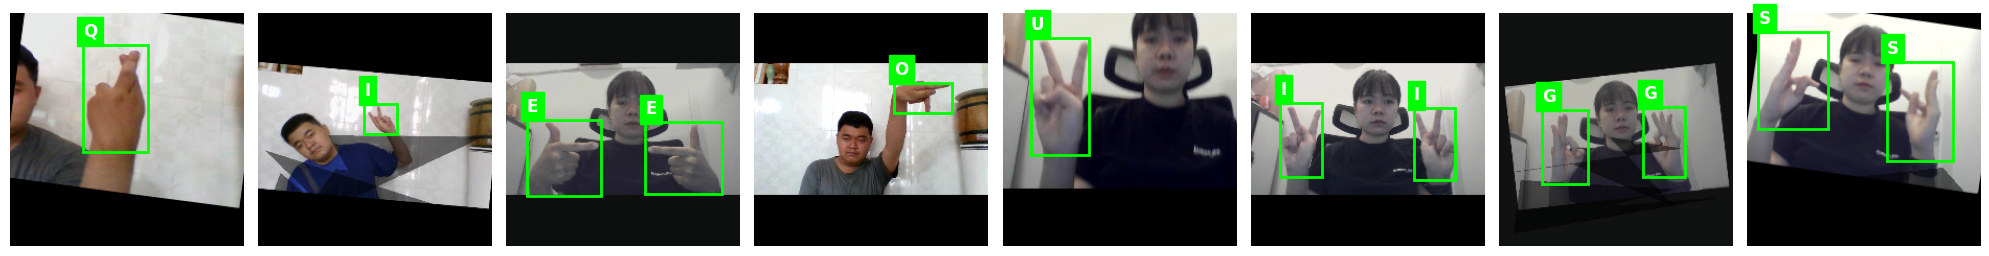

In [ ]:
visualize_augmented_data(train_dataset, num_samples=8)

In [ ]:
# Initialize model, optimizer, loss, and scheduler
print("Initializing model and training components...")

# Create model
model = DETR(num_classes=num_classes, hidden_dim=256, nheads=8,
             num_encoder_layers=1, num_decoder_layers=1, num_queries=25)
model = model.to(device)
print(f"Model moved to {device}")

# Loss weights
weights = {
    'class_weighting': 1.0,
    'bbox_weighting': 5.0,
    'giou_weighting': 2.0
}

# Create matcher and loss function
matcher = HungarianMatcher(weights)
criterion = DETRLoss(num_classes=num_classes, matcher=matcher,
                     weight_dict=weights, eos_coef=0.1)
criterion = criterion.to(device)
# Optimizer and scheduler
param_dicts = [
    {
        "params": [p for n, p in model.named_parameters() if "backbone" not in n and p.requires_grad],
        "lr": 1e-4
    },
    {
        "params": [p for n, p in model.named_parameters() if "backbone" in n and p.requires_grad],
        "lr": 1e-5
    },
]

optimizer = torch.optim.AdamW(
    param_dicts,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[60, 80], gamma=0.1)
print("Model initialized successfully!")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Initializing model and training components...
Model moved to cuda
Model initialized successfully!
Total parameters: 13,571,231
Trainable parameters: 13,571,231


##Training

In [ ]:
output_dir = '/content/drive/MyDrive/NCKH_SignDETR_VSL/v3/tiny_vit/11m/base/output'
log_dir = '/content/drive/MyDrive/NCKH_SignDETR_VSL/v3/tiny_vit/11m/base/logs'

In [ ]:
import time
import copy
from tqdm import tqdm
import shutil
# Lưu backup sau mỗi epoch

def train_one_epoch(model, dataloader, criterion, optimizer, device, weights):
    model.train()
    total_loss_epoch = 0.0
    loss_ce_epoch = 0.0
    loss_bbox_epoch = 0.0
    loss_giou_epoch = 0.0

    # Dùng tqdm để tạo thanh tiến trình
    pbar = tqdm(dataloader, desc="Training", leave=False)
    for images, targets in pbar:
        # Chuyển dữ liệu lên GPU/CPU
        images = images.to(device)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # Forward pass
        outputs = model(images)
        loss_dict = criterion(outputs, targets)

        # Lấy từng thành phần loss
        loss_ce = loss_dict['labels']['loss_ce']
        loss_bbox = loss_dict['boxes']['loss_bbox']
        loss_giou = loss_dict['boxes']['loss_giou']

        loss = (weights['class_weighting'] * loss_ce +
                weights['bbox_weighting'] * loss_bbox +
                weights['giou_weighting'] * loss_giou)

        # Backward pass và tối ưu hóa
        optimizer.zero_grad()
        loss.backward()

        # Gradient clipping: Giúp DETR hội tụ ổn định hơn
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.1)
        optimizer.step()

        # Cộng dồn loss để tính trung bình
        total_loss_epoch += loss.item()
        loss_ce_epoch += loss_ce.item()
        loss_bbox_epoch += loss_bbox.item()
        loss_giou_epoch += loss_giou.item()

        pbar.set_postfix({'Loss': f"{loss.item():.4f}"})

    n = len(dataloader)
    return {
        'total_loss': total_loss_epoch / n,
        'loss_ce': loss_ce_epoch / n,
        'loss_bbox': loss_bbox_epoch / n,
        'loss_giou': loss_giou_epoch / n
    }

@torch.no_grad()
def evaluate(model, dataloader, criterion, device, weights):
    model.eval()
    total_loss_epoch = 0.0
    loss_ce_epoch = 0.0
    loss_bbox_epoch = 0.0
    loss_giou_epoch = 0.0

    pbar = tqdm(dataloader, desc="Evaluating", leave=False)
    for images, targets in pbar:
        images = images.to(device)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        outputs = model(images)
        loss_dict = criterion(outputs, targets)

        loss_ce = loss_dict['labels']['loss_ce']
        loss_bbox = loss_dict['boxes']['loss_bbox']
        loss_giou = loss_dict['boxes']['loss_giou']

        loss = (weights['class_weighting'] * loss_ce +
                weights['bbox_weighting'] * loss_bbox +
                weights['giou_weighting'] * loss_giou)

        total_loss_epoch += loss.item()
        loss_ce_epoch += loss_ce.item()
        loss_bbox_epoch += loss_bbox.item()
        loss_giou_epoch += loss_giou.item()

    n = len(dataloader)
    return {
        'total_loss': total_loss_epoch / n,
        'loss_ce': loss_ce_epoch / n,
        'loss_bbox': loss_bbox_epoch / n,
        'loss_giou': loss_giou_epoch / n
    }

In [ ]:
import os
import time
import json
import torch

drive_dir = '/content/drive/MyDrive/NCKH_SignDETR_VSL/v3/tiny_vit/11m/base/output/'
os.makedirs(drive_dir, exist_ok=True)

# Khai báo các file cần lưu
best_model_path = os.path.join(drive_dir, 'best_signdetr_model.pth')
history_path = os.path.join(drive_dir, 'training_history.json')
log_path = os.path.join(drive_dir, 'training_log.txt')

# Cài đặt tần suất lưu thêm epoch (Ví dụ: 5 epoch lưu 1 lần)
save_freq = 5

# 2. Cấu trúc lưu lịch sử training
history = {
    'train_loss': [], 'val_loss': [],
    'train_ce': [], 'val_ce': [],
    'train_bbox': [], 'val_bbox': [],
    'train_giou': [], 'val_giou': [],
    'lr': []
}

best_val_loss = float('inf')

def log_and_print(text, log_file):
    print(text)
    with open(log_file, 'a', encoding='utf-8') as f:
        f.write(text + '\n')

log_and_print(f"Bắt đầu training {num_epochs} epochs...", log_path)

for epoch in range(num_epochs):
    start_time = time.time()

    # Train 1 epoch
    train_metrics = train_one_epoch(model, train_dataloader, criterion, optimizer, device, weights)

    # Evaluate trên tập validation
    val_metrics = evaluate(model, valid_dataloader, criterion, device, weights)

    # Cập nhật learning rate scheduler
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    # Ghi nhận lịch sử
    history['train_loss'].append(train_metrics['total_loss'])
    history['val_loss'].append(val_metrics['total_loss'])
    history['train_ce'].append(train_metrics['loss_ce'])
    history['val_ce'].append(val_metrics['loss_ce'])
    history['train_bbox'].append(train_metrics['loss_bbox'])
    history['val_bbox'].append(val_metrics['loss_bbox'])
    history['train_giou'].append(train_metrics['loss_giou'])
    history['val_giou'].append(val_metrics['loss_giou'])
    history['lr'].append(current_lr)

    # LƯU HISTORY THÀNH FILE JSON
    with open(history_path, 'w', encoding='utf-8') as f:
        json.dump(history, f, indent=4)

    saved_msg = ""

    # LƯU MODEL TỐT NHẤT (BEST MODEL)
    if val_metrics['total_loss'] < best_val_loss:
        best_val_loss = val_metrics['total_loss']
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': best_val_loss,
        }, best_model_path)
        saved_msg += " [Best Model]"

    # LƯU THÊM CÁC EPOCH ĐỊNH KỲ HOẶC EPOCH CUỐI CÙNG (CHECKPOINT)
    if (epoch + 1) % save_freq == 0 or (epoch + 1) == num_epochs:
        checkpoint_path = os.path.join(drive_dir, f'checkpoint_epoch_{epoch+1:03d}.pth')
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': val_metrics['total_loss'],
        }, checkpoint_path)
        saved_msg += f" [Saved Checkpoint Ep {epoch+1}]"

    epoch_time = time.time() - start_time

    # GHI LOG CHO EPOCH HIỆN TẠI
    log_str1 = f"Epoch {epoch+1:03d}/{num_epochs} | Thời gian: {epoch_time:.0f}s | LR: {current_lr:.2e}"
    log_str2 = f"  Train Loss: {train_metrics['total_loss']:.4f} (CE:{train_metrics['loss_ce']:.4f}, BBox:{train_metrics['loss_bbox']:.4f}, GIoU:{train_metrics['loss_giou']:.4f})"
    log_str3 = f"  Val Loss:   {val_metrics['total_loss']:.4f} (CE:{val_metrics['loss_ce']:.4f}, BBox:{val_metrics['loss_bbox']:.4f}, GIoU:{val_metrics['loss_giou']:.4f}){saved_msg}\n"

    log_and_print(log_str1, log_path)
    log_and_print(log_str2, log_path)
    log_and_print(log_str3, log_path)

log_and_print("Training hoàn tất!", log_path)

Bắt đầu training 100 epochs...


Epoch 001/100 | Thời gian: 125s | LR: 1.00e-04
  Train Loss: 4.4575 (CE:1.8933, BBox:0.2540, GIoU:0.6471)
  Val Loss:   3.8887 (CE:1.8234, BBox:0.1691, GIoU:0.6099) [Best Model]



Epoch 002/100 | Thời gian: 114s | LR: 1.00e-04
  Train Loss: 4.2200 (CE:1.8664, BBox:0.2306, GIoU:0.6003)
  Val Loss:   3.8538 (CE:1.8974, BBox:0.1533, GIoU:0.5949) [Best Model]



Epoch 003/100 | Thời gian: 108s | LR: 1.00e-04
  Train Loss: 4.1165 (CE:1.8632, BBox:0.2193, GIoU:0.5785)
  Val Loss:   3.5889 (CE:1.8537, BBox:0.1354, GIoU:0.5291) [Best Model]



Epoch 004/100 | Thời gian: 107s | LR: 1.00e-04
  Train Loss: 4.0423 (CE:1.8613, BBox:0.2107, GIoU:0.5637)
  Val Loss:   3.5723 (CE:1.8410, BBox:0.1332, GIoU:0.5327) [Best Model]



...

Epoch 096/100 | Thời gian: 91s | LR: 1.00e-06
  Train Loss: 1.3885 (CE:0.6581, BBox:0.0622, GIoU:0.2098)
  Val Loss:   1.0735 (CE:0.5813, BBox:0.0344, GIoU:0.1601)



Epoch 097/100 | Thời gian: 90s | LR: 1.00e-06
  Train Loss: 1.4062 (CE:0.6736, BBox:0.0629, GIoU:0.2091)
  Val Loss:   1.0766 (CE:0.5854, BBox:0.0343, GIoU:0.1597)



Epoch 098/100 | Thời gian: 88s | LR: 1.00e-06
  Train Loss: 1.3970 (CE:0.6610, BBox:0.0634, GIoU:0.2095)
  Val Loss:   1.0572 (CE:0.5801, BBox:0.0336, GIoU:0.1547) [Best Model]



Epoch 099/100 | Thời gian: 97s | LR: 1.00e-06
  Train Loss: 1.4210 (CE:0.6683, BBox:0.0649, GIoU:0.2141)
  Val Loss:   1.0598 (CE:0.5849, BBox:0.0333, GIoU:0.1542)



Epoch 100/100 | Thời gian: 91s | LR: 1.00e-06
  Train Loss: 1.3928 (CE:0.6610, BBox:0.0635, GIoU:0.2071)
  Val Loss:   1.0703 (CE:0.5814, BBox:0.0341, GIoU:0.1592) [Saved Checkpoint Ep 100]

Training hoàn tất!


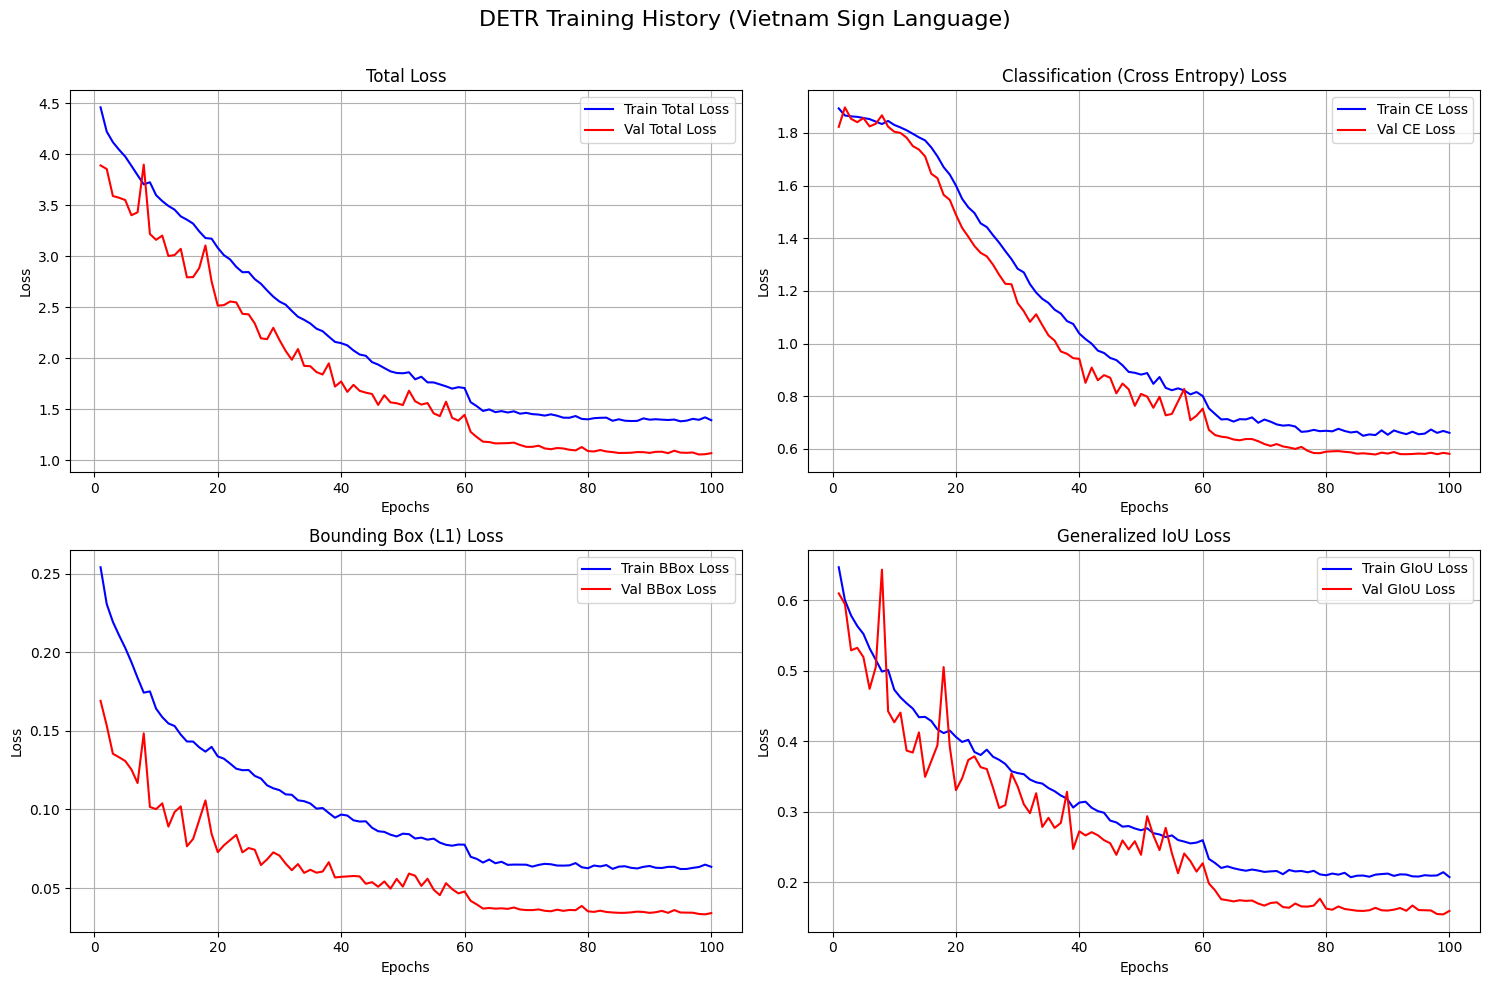

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    epochs = range(1, len(history['train_loss']) + 1)

    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('DETR Training History (Vietnam Sign Language)', fontsize=16)

    # 1. Total Loss
    axs[0, 0].plot(epochs, history['train_loss'], 'b-', label='Train Total Loss')
    axs[0, 0].plot(epochs, history['val_loss'], 'r-', label='Val Total Loss')
    axs[0, 0].set_title('Total Loss')
    axs[0, 0].set_xlabel('Epochs')
    axs[0, 0].set_ylabel('Loss')
    axs[0, 0].legend()
    axs[0, 0].grid(True)

    # 2. Classification Loss
    axs[0, 1].plot(epochs, history['train_ce'], 'b-', label='Train CE Loss')
    axs[0, 1].plot(epochs, history['val_ce'], 'r-', label='Val CE Loss')
    axs[0, 1].set_title('Classification (Cross Entropy) Loss')
    axs[0, 1].set_xlabel('Epochs')
    axs[0, 1].set_ylabel('Loss')
    axs[0, 1].legend()
    axs[0, 1].grid(True)

    # 3. Bounding Box L1 Loss
    axs[1, 0].plot(epochs, history['train_bbox'], 'b-', label='Train BBox Loss')
    axs[1, 0].plot(epochs, history['val_bbox'], 'r-', label='Val BBox Loss')
    axs[1, 0].set_title('Bounding Box (L1) Loss')
    axs[1, 0].set_xlabel('Epochs')
    axs[1, 0].set_ylabel('Loss')
    axs[1, 0].legend()
    axs[1, 0].grid(True)

    # 4. GIoU Loss
    axs[1, 1].plot(epochs, history['train_giou'], 'b-', label='Train GIoU Loss')
    axs[1, 1].plot(epochs, history['val_giou'], 'r-', label='Val GIoU Loss')
    axs[1, 1].set_title('Generalized IoU Loss')
    axs[1, 1].set_xlabel('Epochs')
    axs[1, 1].set_ylabel('Loss')
    axs[1, 1].legend()
    axs[1, 1].grid(True)

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

# Gọi hàm để vẽ biểu đồ
plot_training_history(history)

In [ ]:

test_dataloader = DataLoader(
    test_dataset,
    batch_size=8,
    collate_fn=stacker,
    drop_last=False
)


In [ ]:
MODEL_PATH = "/content/drive/MyDrive/NCKH_SignDETR_VSL/v3/tiny_vit/11m/base/output/best_signdetr_model.pth"


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DETR(num_classes=22)
checkpoint = torch.load(MODEL_PATH)
if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)
model.to(device)

model.eval()



print("Mô hình đã sẵn sàng.")

Mô hình đã sẵn sàng.


In [ ]:

import torch
import torch.nn.functional as F
from tqdm import tqdm
import time
@torch.no_grad()
def calculate_accuracy_and_deviation(
    model,
    dataloader,
    matcher,
    device,
    topk=3,
    conf_threshold=0.35,
    iou_threshold=0.5,
):
    model.eval()

    total_matched_objects = 0
    correct_top1_predictions = 0
    correct_topk_predictions = 0
    confident_objects = 0
    confident_correct_top1 = 0
    confidence_sum = 0.0

    iou_sum = 0.0
    iou_pass_count = 0

    total_box_deviation = 0.0

    # Biến để lưu sai số riêng cho từng thành phần (Tùy chọn xem chi tiết)
    dev_cx, dev_cy, dev_w, dev_h = 0.0, 0.0, 0.0, 0.0

    num_classes = None
    class_total = None
    class_correct = None

    pbar = tqdm(dataloader, desc="Calculating Accuracy & Deviation")
    for images, targets in pbar:
        images = images.to(device)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # 1. Chạy model để lấy dự đoán
        outputs = model(images)

        # 2. Dùng HungarianMatcher để tìm ra các dự đoán khớp với Ground Truth nhất
        indices = matcher(outputs, targets)

        if num_classes is None:
            # outputs['pred_logits'] includes no-object at the last index
            num_classes = outputs['pred_logits'].shape[-1] - 1
            class_total = [0 for _ in range(num_classes)]
            class_correct = [0 for _ in range(num_classes)]

        for batch_idx, (pred_idx, tgt_idx) in enumerate(indices):
            # Lấy ra các dự đoán và đáp án đã được ghép cặp (matched)
            pred_logits_matched = outputs['pred_logits'][batch_idx, pred_idx]
            pred_boxes_matched = outputs['pred_boxes'][batch_idx, pred_idx]

            tgt_labels_matched = targets[batch_idx]['labels'][tgt_idx]
            tgt_boxes_matched = targets[batch_idx]['boxes'][tgt_idx]

            num_objects = len(tgt_labels_matched)
            if num_objects == 0:
                continue

            total_matched_objects += num_objects

            # --- TÍNH ACCURACY (Top-1, Top-k, confidence threshold) ---
            class_probs = pred_logits_matched.softmax(dim=-1)[:, :-1]  # drop no-object class
            conf_scores, pred_labels = class_probs.max(dim=-1)

            k_val = min(topk, class_probs.shape[-1])
            topk_labels = class_probs.topk(k=k_val, dim=-1).indices

            is_top1_correct = pred_labels == tgt_labels_matched
            is_topk_correct = (topk_labels == tgt_labels_matched.unsqueeze(1)).any(dim=1)
            confident_mask = conf_scores >= conf_threshold

            correct_top1_predictions += is_top1_correct.sum().item()
            correct_topk_predictions += is_topk_correct.sum().item()
            confident_objects += confident_mask.sum().item()
            confident_correct_top1 += (is_top1_correct & confident_mask).sum().item()
            confidence_sum += conf_scores.sum().item()

            for gt_label, is_correct in zip(tgt_labels_matched, is_top1_correct):
                gt_id = int(gt_label.item())
                if 0 <= gt_id < num_classes:
                    class_total[gt_id] += 1
                    if bool(is_correct.item()):
                        class_correct[gt_id] += 1

            # --- TÍNH mIoU + tỉ lệ IoU đạt ngưỡng ---
            pred_xyxy = box_cxcywh_to_xyxy(pred_boxes_matched)
            tgt_xyxy = box_cxcywh_to_xyxy(tgt_boxes_matched)
            iou_matrix, _ = box_iou(pred_xyxy, tgt_xyxy)
            matched_iou = torch.diag(iou_matrix)
            iou_sum += matched_iou.sum().item()
            iou_pass_count += (matched_iou >= iou_threshold).sum().item()

            # --- TÍNH ĐỘ LỆCH (Box Deviation - L1 Error) ---
            # Tính sai số tuyệt đối trung bình cho 4 tọa độ (cx, cy, w, h)
            # Tọa độ đang ở dạng chuẩn hóa (0 -> 1)
            deviation = F.l1_loss(pred_boxes_matched, tgt_boxes_matched, reduction='sum').item()
            total_box_deviation += deviation

            # Tính sai số chi tiết cho tâm (cx, cy) và kích thước (w, h)
            abs_diff = torch.abs(pred_boxes_matched - tgt_boxes_matched)
            dev_cx += abs_diff[:, 0].sum().item()
            dev_cy += abs_diff[:, 1].sum().item()
            dev_w  += abs_diff[:, 2].sum().item()
            dev_h  += abs_diff[:, 3].sum().item()

    # Tổng hợp kết quả
    if total_matched_objects == 0:
        print("Không tìm thấy đối tượng nào trong tập test!")
        return {}

    top1_accuracy = (correct_top1_predictions / total_matched_objects) * 100
    topk_accuracy = (correct_topk_predictions / total_matched_objects) * 100
    confident_accuracy = (
        (confident_correct_top1 / confident_objects) * 100 if confident_objects > 0 else 0.0
    )
    avg_confidence = confidence_sum / total_matched_objects
    mean_iou = iou_sum / total_matched_objects
    iou_pass_rate = (iou_pass_count / total_matched_objects) * 100

    # Chia cho (số object * 4 tọa độ) để ra độ lệch trung bình trên mỗi trục tọa độ
    avg_deviation = total_box_deviation / (total_matched_objects * 4)

    avg_dev_cx = dev_cx / total_matched_objects
    avg_dev_cy = dev_cy / total_matched_objects
    avg_dev_w  = dev_w / total_matched_objects
    avg_dev_h  = dev_h / total_matched_objects

    print("\n" + "="*50)
    print(" KẾT QUẢ ACCURACY & ĐỘ LỆCH TRÊN TẬP TEST ".center(50))
    print("="*50)
    print(f"Tổng số đối tượng được test : {total_matched_objects}")
    print(f"Top-1 Accuracy             : {top1_accuracy:.2f}% ({correct_top1_predictions}/{total_matched_objects})")
    print(f"Top-{min(topk, num_classes)} Accuracy           : {topk_accuracy:.2f}% ({correct_topk_predictions}/{total_matched_objects})")
    print(f"Confident Top-1 Accuracy   : {confident_accuracy:.2f}% (thr={conf_threshold}, {confident_correct_top1}/{confident_objects})")
    print(f"Mean confidence            : {avg_confidence:.4f}")
    print(f"Mean IoU                   : {mean_iou:.4f}")
    print(f"IoU@{iou_threshold} pass rate     : {iou_pass_rate:.2f}% ({iou_pass_count}/{total_matched_objects})")
    print("-" * 50)
    print(f"Độ lệch tổng thể (Trung bình): {avg_deviation:.4f} (theo tỷ lệ ảnh 0-1)")
    print("Chi tiết độ lệch từng thông số:")
    print(f"  - Lệch tọa độ X (cx)       : {avg_dev_cx:.4f} (~{avg_dev_cx*100:.2f}% chiều rộng ảnh)")
    print(f"  - Lệch tọa độ Y (cy)       : {avg_dev_cy:.4f} (~{avg_dev_cy*100:.2f}% chiều cao ảnh)")
    print(f"  - Lệch chiều rộng (w)      : {avg_dev_w:.4f}  (~{avg_dev_w*100:.2f}% chiều rộng ảnh)")
    print(f"  - Lệch chiều cao (h)       : {avg_dev_h:.4f}  (~{avg_dev_h*100:.2f}% chiều cao ảnh)")

    if class_total is not None and class_correct is not None:
        per_class_stats = []
        for cls_id in range(num_classes):
            total_cls = class_total[cls_id]
            if total_cls == 0:
                continue
            acc_cls = 100.0 * class_correct[cls_id] / total_cls
            per_class_stats.append((cls_id, acc_cls, class_correct[cls_id], total_cls))

        if per_class_stats:
            per_class_stats.sort(key=lambda x: x[1])
            print("-" * 50)
            print("5 lớp yếu nhất (Top-1):")
            for cls_id, acc_cls, c_ok, c_total in per_class_stats[:5]:
                print(f"  - Class {cls_id:>2}: {acc_cls:6.2f}% ({c_ok}/{c_total})")

    print("="*50)

    return {
        "total_objects": total_matched_objects,
        "top1_accuracy": top1_accuracy,
        "topk_accuracy": topk_accuracy,
        "confident_accuracy": confident_accuracy,
        "mean_confidence": avg_confidence,
        "mean_iou": mean_iou,
        "iou_pass_rate": iou_pass_rate,
        "avg_deviation": avg_deviation,
        "avg_dev_cx": avg_dev_cx,
        "avg_dev_cy": avg_dev_cy,
        "avg_dev_w": avg_dev_w,
        "avg_dev_h": avg_dev_h,
    }

# Gọi hàm để tính toán
eval_stats = calculate_accuracy_and_deviation(
    model,
    test_dataloader,
    matcher,
    device,
    topk=3,
    conf_threshold=0.35,
    iou_threshold=0.5,
)


def _ap_from_ranked_predictions(records, num_gt):
    """Compute AP from ranked predictions.

    records: list of tuples (score, tp, fp)
    num_gt: number of GT objects for this class (or class-size group)
    """
    if num_gt <= 0:
        return None
    if not records:
        return 0.0

    records = sorted(records, key=lambda x: x[0], reverse=True)
    tps = np.array([r[1] for r in records], dtype=np.float32)
    fps = np.array([r[2] for r in records], dtype=np.float32)

    tp_cum = np.cumsum(tps)
    fp_cum = np.cumsum(fps)

    recalls = tp_cum / max(float(num_gt), 1e-12)
    precisions = tp_cum / np.maximum(tp_cum + fp_cum, 1e-12)

    mrec = np.concatenate(([0.0], recalls, [1.0]))
    mpre = np.concatenate(([0.0], precisions, [0.0]))

    # Precision envelope
    for i in range(len(mpre) - 1, 0, -1):
        mpre[i - 1] = max(mpre[i - 1], mpre[i])

    idx = np.where(mrec[1:] != mrec[:-1])[0]
    ap = np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1])
    return float(ap)


def _mask_by_area_bin(areas, bin_name, small_thr, medium_thr):
    if bin_name == "small":
        return areas < small_thr
    if bin_name == "medium":
        return (areas >= small_thr) & (areas < medium_thr)
    return areas >= medium_thr


@torch.no_grad()
def calculate_map_metrics(
    model,
    dataloader,
    device,
    score_threshold=0.05,
    iou_thresholds=None,
    input_size_for_bins=512,
):
    """Compute COCO-style metrics (approx): mAP, AP50, AP75, AP by object size."""
    model.eval()

    if iou_thresholds is None:
        iou_thresholds = [round(x, 2) for x in np.arange(0.50, 0.96, 0.05)]

    # COCO-like object size thresholds, converted to normalized area
    img_area = float(input_size_for_bins * input_size_for_bins)
    small_thr = (32.0 * 32.0) / img_area
    medium_thr = (96.0 * 96.0) / img_area

    num_classes = None

    records = {}  # records[iou][class] -> [(score, tp, fp), ...]
    gt_counts = {}  # gt_counts[class]

    size_bins = ("small", "medium", "large")
    records_by_size = {b: {} for b in size_bins}
    gt_counts_by_size = {b: {} for b in size_bins}

    for images, targets in tqdm(dataloader, desc="Calculating mAP/AP"):
        images = images.to(device)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        outputs = model(images)

        if num_classes is None:
            num_classes = outputs["pred_logits"].shape[-1] - 1
            for thr in iou_thresholds:
                records[thr] = {c: [] for c in range(num_classes)}
                for b in size_bins:
                    records_by_size[b][thr] = {c: [] for c in range(num_classes)}
            gt_counts = {c: 0 for c in range(num_classes)}
            for b in size_bins:
                gt_counts_by_size[b] = {c: 0 for c in range(num_classes)}

        batch_size = images.shape[0]
        for b_idx in range(batch_size):
            logits = outputs["pred_logits"][b_idx]
            pred_boxes = outputs["pred_boxes"][b_idx]

            probs = logits.softmax(dim=-1)[:, :-1]  # exclude no-object class
            pred_scores, pred_labels = probs.max(dim=-1)
            keep = pred_scores >= score_threshold

            pred_scores = pred_scores[keep]
            pred_labels = pred_labels[keep]
            pred_boxes = pred_boxes[keep]

            pred_xyxy = box_cxcywh_to_xyxy(pred_boxes)
            pred_areas = ((pred_xyxy[:, 2] - pred_xyxy[:, 0]).clamp(min=0.0) *
                          (pred_xyxy[:, 3] - pred_xyxy[:, 1]).clamp(min=0.0))

            gt_labels = targets[b_idx]["labels"].long()
            gt_boxes = targets[b_idx]["boxes"].float()
            gt_xyxy = box_cxcywh_to_xyxy(gt_boxes)
            gt_areas = ((gt_xyxy[:, 2] - gt_xyxy[:, 0]).clamp(min=0.0) *
                        (gt_xyxy[:, 3] - gt_xyxy[:, 1]).clamp(min=0.0))

            for cls_id in range(num_classes):
                cls_pred_mask = pred_labels == cls_id
                cls_gt_mask = gt_labels == cls_id

                cls_pred_scores = pred_scores[cls_pred_mask]
                cls_pred_boxes = pred_xyxy[cls_pred_mask]
                cls_pred_areas = pred_areas[cls_pred_mask]

                cls_gt_boxes = gt_xyxy[cls_gt_mask]
                cls_gt_areas = gt_areas[cls_gt_mask]

                num_gt = int(cls_gt_boxes.shape[0])
                gt_counts[cls_id] += num_gt

                for bname in size_bins:
                    gt_bin_mask = _mask_by_area_bin(cls_gt_areas, bname, small_thr, medium_thr)
                    gt_counts_by_size[bname][cls_id] += int(gt_bin_mask.sum().item())

                if cls_pred_scores.numel() > 0:
                    order = torch.argsort(cls_pred_scores, descending=True)
                    cls_pred_scores = cls_pred_scores[order]
                    cls_pred_boxes = cls_pred_boxes[order]
                    cls_pred_areas = cls_pred_areas[order]

                # Global AP per class
                for thr in iou_thresholds:
                    matched_gt = set()
                    for p_i in range(cls_pred_boxes.shape[0]):
                        score = float(cls_pred_scores[p_i].item())

                        if num_gt == 0:
                            records[thr][cls_id].append((score, 0, 1))
                            continue

                        ious, _ = box_iou(cls_pred_boxes[p_i].unsqueeze(0), cls_gt_boxes)
                        ious = ious[0]
                        best_iou, best_j = torch.max(ious, dim=0)
                        best_iou = float(best_iou.item())
                        best_j = int(best_j.item())

                        if best_iou >= thr and best_j not in matched_gt:
                            matched_gt.add(best_j)
                            records[thr][cls_id].append((score, 1, 0))
                        else:
                            records[thr][cls_id].append((score, 0, 1))

                # AP by size bin (approx): evaluate predictions and GT in the same area bin
                for bname in size_bins:
                    pred_bin_mask = _mask_by_area_bin(cls_pred_areas, bname, small_thr, medium_thr)
                    gt_bin_mask = _mask_by_area_bin(cls_gt_areas, bname, small_thr, medium_thr)

                    pred_scores_bin = cls_pred_scores[pred_bin_mask]
                    pred_boxes_bin = cls_pred_boxes[pred_bin_mask]
                    gt_boxes_bin = cls_gt_boxes[gt_bin_mask]

                    num_gt_bin = int(gt_boxes_bin.shape[0])

                    for thr in iou_thresholds:
                        matched_gt_bin = set()
                        for p_i in range(pred_boxes_bin.shape[0]):
                            score = float(pred_scores_bin[p_i].item())

                            if num_gt_bin == 0:
                                records_by_size[bname][thr][cls_id].append((score, 0, 1))
                                continue

                            ious, _ = box_iou(pred_boxes_bin[p_i].unsqueeze(0), gt_boxes_bin)
                            ious = ious[0]
                            best_iou, best_j = torch.max(ious, dim=0)
                            best_iou = float(best_iou.item())
                            best_j = int(best_j.item())

                            if best_iou >= thr and best_j not in matched_gt_bin:
                                matched_gt_bin.add(best_j)
                                records_by_size[bname][thr][cls_id].append((score, 1, 0))
                            else:
                                records_by_size[bname][thr][cls_id].append((score, 0, 1))

    if num_classes is None:
        print("No predictions found for mAP calculation")
        return {}

    def mean_ap_at_threshold(thr, rec_dict, gt_dict):
        aps = []
        for c in range(num_classes):
            ap = _ap_from_ranked_predictions(rec_dict[thr][c], gt_dict[c])
            if ap is not None:
                aps.append(ap)
        return float(np.mean(aps)) if aps else 0.0

    ap50 = mean_ap_at_threshold(0.50, records, gt_counts)
    ap75 = mean_ap_at_threshold(0.75, records, gt_counts)

    map_per_thr = [mean_ap_at_threshold(thr, records, gt_counts) for thr in iou_thresholds]
    map_50_95 = float(np.mean(map_per_thr)) if map_per_thr else 0.0

    ap_by_size = {}
    for bname in size_bins:
        vals = [
            mean_ap_at_threshold(thr, records_by_size[bname], gt_counts_by_size[bname])
            for thr in iou_thresholds
        ]
        ap_by_size[bname] = float(np.mean(vals)) if vals else 0.0

    print("\n" + "=" * 62)
    print(" DETECTION METRICS (COCO-STYLE APPROX) ".center(62))
    print("=" * 62)
    print(f"mAP@[0.50:0.95] : {map_50_95 * 100:.2f}")
    print(f"AP50            : {ap50 * 100:.2f}")
    print(f"AP75            : {ap75 * 100:.2f}")
    print(f"AP small        : {ap_by_size['small'] * 100:.2f}")
    print(f"AP medium       : {ap_by_size['medium'] * 100:.2f}")
    print(f"AP large        : {ap_by_size['large'] * 100:.2f}")
    print("=" * 62)

    return {
        "mAP_50_95": map_50_95,
        "AP50": ap50,
        "AP75": ap75,
        "AP_small": ap_by_size["small"],
        "AP_medium": ap_by_size["medium"],
        "AP_large": ap_by_size["large"],
    }


@torch.no_grad()
def measure_efficiency_metrics(model, dataloader, device, warmup_steps=10, measure_steps=50):
    """Measure FPS, latency, parameter count, and estimate GFLOPs."""
    model.eval()

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    # Estimate GFLOPs if torchinfo is available
    gflops_est = None
    try:
        from torchinfo import summary as torchinfo_summary
        stats = torchinfo_summary(model, input_size=(1, 3, 512, 512), verbose=0)
        if getattr(stats, "total_mult_adds", None) is not None:
            # total_mult_adds is MACs, commonly reported as FLOPs in quick model audits
            gflops_est = float(stats.total_mult_adds) / 1e9
    except Exception:
        gflops_est = None

    # Warmup
    step = 0
    for images, _ in dataloader:
        images = images.to(device)
        _ = model(images)
        step += 1
        if step >= warmup_steps:
            break

    # Timed inference
    start_t = time.time()
    measured_steps = 0
    measured_images = 0
    for images, _ in dataloader:
        images = images.to(device)
        if device.type == "cuda":
            torch.cuda.synchronize()
        _ = model(images)
        if device.type == "cuda":
            torch.cuda.synchronize()

        measured_steps += 1
        measured_images += int(images.shape[0])
        if measured_steps >= measure_steps:
            break

    elapsed = max(time.time() - start_t, 1e-12)
    fps = measured_images / elapsed
    latency_ms = (elapsed / measured_images) * 1000.0

    print("\n" + "=" * 62)
    print(" EFFICIENCY METRICS ".center(62))
    print("=" * 62)
    print(f"Parameters (total)   : {total_params:,}")
    print(f"Parameters (train)   : {trainable_params:,}")
    print(f"GFLOPs (est.)        : {gflops_est:.2f}" if gflops_est is not None else "GFLOPs (est.)        : N/A")
    print(f"FPS                  : {fps:.2f}")
    print(f"Latency / image (ms) : {latency_ms:.2f}")
    print("=" * 62)

    return {
        "params_total": total_params,
        "params_trainable": trainable_params,
        "gflops_est": gflops_est,
        "fps": fps,
        "latency_ms": latency_ms,
    }


map_stats = calculate_map_metrics(
    model,
    test_dataloader,
    device,
    score_threshold=0.05,
    iou_thresholds=[round(x, 2) for x in np.arange(0.50, 0.96, 0.05)],
    input_size_for_bins=512,
)

eff_stats = measure_efficiency_metrics(
    model,
    test_dataloader,
    device,
    warmup_steps=10,
    measure_steps=50,
)






Calculating Accuracy & Deviation: 100%|██████████| 42/42 [00:08<00:00,  4.92it/s]



     KẾT QUẢ ACCURACY & ĐỘ LỆCH TRÊN TẬP TEST     
Tổng số đối tượng được test : 480
Top-1 Accuracy             : 93.75% (450/480)
Top-3 Accuracy           : 97.71% (469/480)
Confident Top-1 Accuracy   : 98.27% (thr=0.35, 397/404)
Mean confidence            : 0.5935
Mean IoU                   : 0.8474
IoU@0.5 pass rate     : 99.79% (479/480)
--------------------------------------------------
Độ lệch tổng thể (Trung bình): 0.0081 (theo tỷ lệ ảnh 0-1)
Chi tiết độ lệch từng thông số:
  - Lệch tọa độ X (cx)       : 0.0057 (~0.57% chiều rộng ảnh)
  - Lệch tọa độ Y (cy)       : 0.0066 (~0.66% chiều cao ảnh)
  - Lệch chiều rộng (w)      : 0.0099  (~0.99% chiều rộng ảnh)
  - Lệch chiều cao (h)       : 0.0102  (~1.02% chiều cao ảnh)
--------------------------------------------------
5 lớp yếu nhất (Top-1):
  - Class 15:  65.22% (15/23)
  - Class  8:  71.43% (15/21)
  - Class 18:  78.95% (15/19)
  - Class  9:  90.48% (19/21)
  - Class 10:  90.48% (19/21)


Calculating mAP/AP: 100%|██████████| 42/42 [00:59<00:00,  1.41s/it]



            DETECTION METRICS (COCO-STYLE APPROX)             
mAP@[0.50:0.95] : 31.48
AP50            : 46.28
AP75            : 37.50
AP small        : 0.00
AP medium       : 19.16
AP large        : 42.28

                      EFFICIENCY METRICS                      
Parameters (total)   : 13,571,231
Parameters (train)   : 13,571,231
GFLOPs (est.)        : 2.19
FPS                  : 56.96
Latency / image (ms) : 17.56


In [ ]:

import torch
import torch.nn.functional as F
from tqdm import tqdm

@torch.no_grad()
def calculate_advanced_metrics(model, dataloader, matcher, device, id2name):
    model.eval()

    total_matched_objects = 0
    correct_class_predictions = 0
    total_box_deviation = 0.0
    total_iou = 0.0

    # Dictionary để theo dõi số lượng và độ chính xác của từng chữ cái
    class_totals = {i: 0 for i in id2name.keys()}
    class_corrects = {i: 0 for i in id2name.keys()}

    pbar = tqdm(dataloader, desc="Calculating Advanced Metrics")
    for images, targets in pbar:
        images = images.to(device)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        outputs = model(images)
        indices = matcher(outputs, targets)

        for batch_idx, (pred_idx, tgt_idx) in enumerate(indices):
            pred_logits_matched = outputs['pred_logits'][batch_idx, pred_idx]
            pred_boxes_matched = outputs['pred_boxes'][batch_idx, pred_idx]

            tgt_labels_matched = targets[batch_idx]['labels'][tgt_idx]
            tgt_boxes_matched = targets[batch_idx]['boxes'][tgt_idx]

            num_objects = len(tgt_labels_matched)
            if num_objects == 0:
                continue

            total_matched_objects += num_objects

            # --- 1. TÍNH ACCURACY & PER-CLASS ACCURACY ---
            pred_labels = pred_logits_matched.argmax(dim=-1)
            correct_mask = (pred_labels == tgt_labels_matched)
            correct_class_predictions += correct_mask.sum().item()

            # Thống kê chi tiết cho từng chữ cái
            for p_label, t_label, is_correct in zip(pred_labels, tgt_labels_matched, correct_mask):
                t_id = t_label.item()
                if t_id in class_totals:
                    class_totals[t_id] += 1
                    if is_correct.item():
                        class_corrects[t_id] += 1

            # --- 2. TÍNH ĐỘ LỆCH (L1 Deviation) ---
            deviation = F.l1_loss(pred_boxes_matched, tgt_boxes_matched, reduction='sum').item()
            total_box_deviation += deviation

            # --- 3. TÍNH mIoU (mean Intersection over Union) ---
            # Chuyển đổi về dạng [x1, y1, x2, y2] để tính IoU
            pred_xyxy = box_cxcywh_to_xyxy(pred_boxes_matched)
            tgt_xyxy = box_cxcywh_to_xyxy(tgt_boxes_matched)

            # Hàm box_iou trả về ma trận NxN, ta lấy đường chéo (diag) vì các box đã được match 1-1
            iou_matrix, _ = box_iou(pred_xyxy, tgt_xyxy)
            matched_iou = torch.diag(iou_matrix)
            total_iou += matched_iou.sum().item()

    # ================= HIỂN THỊ KẾT QUẢ =================
    if total_matched_objects == 0:
        print("Không tìm thấy đối tượng nào trong tập test!")
        return

    accuracy = (correct_class_predictions / total_matched_objects) * 100
    avg_deviation = total_box_deviation / (total_matched_objects * 4)
    mIoU = (total_iou / total_matched_objects) * 100

    print("\n" + "="*50)
    print(" BÁO CÁO ĐÁNH GIÁ MÔ HÌNH NHẬN DIỆN VSL ".center(50))
    print("="*50)
    print(f"Tổng số bàn tay được test: {total_matched_objects}")
    print(f"1. Độ chính xác tổng thể : {accuracy:.2f}%")
    print(f"2. Độ lệch tọa độ (L1)   : {avg_deviation:.4f}")
    print(f"3. Chỉ số mIoU (Độ khớp) : {mIoU:.2f}% (Càng gần 100% khung hình càng ôm sát tay)")
    print("-" * 50)

    print("4. CHI TIẾT ĐỘ CHÍNH XÁC TỪNG CHỮ CÁI (Nhận diện điểm mù):")
    # Sắp xếp các class theo độ chính xác từ thấp đến cao để dễ tìm lỗi
    class_accuracies = []
    for cls_id, total in class_totals.items():
        if total > 0:
            acc = (class_corrects[cls_id] / total) * 100
            class_accuracies.append((id2name[cls_id], acc, class_corrects[cls_id], total))

    class_accuracies.sort(key=lambda x: x[1]) # Sắp xếp tăng dần theo accuracy

    for name, acc, correct, total in class_accuracies:
        # Highlight những chữ cái nhận diện kém (< 70%)
        warning = " ⚠️ Cần thêm data" if acc < 70 else ""
        print(f"   - Chữ {name:<3} : {acc:6.2f}% ({correct}/{total}){warning}")
    print("="*50)

# Gọi hàm (nhớ truyền biến id2name vào)
# calculate_advanced_metrics(model, test_dataloader, matcher, device, id2name)

calculate_advanced_metrics(model, test_dataloader, matcher, device, id2name)

Calculating Advanced Metrics: 100%|██████████| 42/42 [00:07<00:00,  5.44it/s]


      BÁO CÁO ĐÁNH GIÁ MÔ HÌNH NHẬN DIỆN VSL      
Tổng số bàn tay được test: 480
1. Độ chính xác tổng thể : 77.29%
2. Độ lệch tọa độ (L1)   : 0.0081
3. Chỉ số mIoU (Độ khớp) : 84.74% (Càng gần 100% khung hình càng ôm sát tay)
--------------------------------------------------
4. CHI TIẾT ĐỘ CHÍNH XÁC TỪNG CHỮ CÁI (Nhận diện điểm mù):
   - Chữ R   :  43.48% (10/23) ⚠️ Cần thêm data
   - Chữ G   :  50.00% (11/22) ⚠️ Cần thêm data
   - Chữ K   :  52.38% (11/21) ⚠️ Cần thêm data
   - Chữ E   :  60.87% (14/23) ⚠️ Cần thêm data
   - Chữ U   :  68.42% (13/19) ⚠️ Cần thêm data
   - Chữ V   :  69.57% (16/23) ⚠️ Cần thêm data
   - Chữ M   :  71.43% (15/21)
   - Chữ H   :  72.00% (18/25)
   - Chữ I   :  75.00% (15/20)
   - Chữ N   :  76.19% (16/21)
   - Chữ Q   :  80.95% (17/21)
   - Chữ B   :  82.61% (19/23)
   - Chữ L   :  85.71% (18/21)
   - Chữ D   :  86.36% (19/22)
   - Chữ O   :  86.96% (20/23)
   - Chữ S   :  87.50% (21/24)
   - Chữ C   :  90.48% (19/21)
   - Chữ T   :  90.48% (19/21)
  

In [ ]:
from google.colab import runtime
runtime.unassign()